# Pair Traiding 

Asumimos que los precios logarítmicos, $X_t = \ln(P^{(1)}_t)$ and $Y_t = \ln(P^{(2)}_t)$, son caminantes aleatorios. Nuestro trabajo es encontrar el vector cointegrante $(1, -\beta)$ de manera tal que el spread $Z_t$ sea estacionario ($I(0)$):

$$Z_t = Y_t - \beta X_t$$

We model the dynamics of this synthetic observable $Z_t$ as an Ornstein-Uhlenbeck (OU) process, which is the continuous-time analogue of the discrete autoregressive AR(1) model. It represents a particle undergoing Brownian motion under the influence of a harmonic potential well (a spring restoring it to equilibrium).$$dZ_t = \theta (\mu - Z_t)dt + \sigma dW_t$$

Where:
$\theta > 0$ is the rate of mean reversion (the stiffness of the spring).
$\mu$ is the long-term equilibrium mean.
$\sigma$ is the volatility of the stochastic shocks.
$dW_t$ is a standard Wiener process.

- To understand the macroscopic behavior of this system, we do not look at single paths. We look at the evolution of its probability density function $p(z,t)$. In physics, the time evolution of the probability density of an OU process is governed by the Fokker-Planck Equation:$$\frac{\partial p(z,t)}{\partial t} = \frac{\partial}{\partial z} \Big[ \theta(z - \mu) p(z,t) \Big] + \frac{1}{2}\sigma^2 \frac{\partial^2 p(z,t)}{\partial z^2}$$Because the system is mean-reverting, it eventually reaches a thermodynamic equilibrium where $\frac{\partial p}{\partial t} = 0$. Solving the stationary Fokker-Planck equation yields the invariant distribution:$$p_{st}(z) = \sqrt{\frac{\theta}{\pi \sigma^2}} \exp\left( - \frac{\theta}{\sigma^2} (z-\mu)^2 \right)$$This proves that the equilibrium distribution of a cointegrated spread is a Gaussian with mean $\mu$ and variance $\frac{\sigma^2}{2\theta}$. This exact mathematical constraint is what justifies the use of a "Z-score" to define entry and exit thresholds.

####  Hedge Ratio ($\beta$)

Realizamos la regresión lineal (OLS) sobre el modelo:

$$ \log A_t= \beta \log B_t + \alpha + \epsilon_t$$

Para comprobar estacionariedad, le realizamos el test aumentado de Dickey-Fuller (ADF). It is a statistical test used to determine whether a time series contains a "unit root" (meaning it is a non-stationary random walk) or if it is stationary (meaning it reverts to a stable equilibrium).

The full equation for the Augmented Dickey-Fuller test is:$$\Delta y_t = \alpha + \beta t + \gamma y_{t-1} + \sum_{i=1}^p \delta_i \Delta y_{t-i} + \epsilon_t$$Where:$\alpha$ is a constant (drift).$\beta t$ is a deterministic time trend.$y_{t-1}$ is the lagged level of the series.$\gamma$ is the critical parameter representing the restoring force.$\sum_{i=1}^p \delta_i \Delta y_{t-i}$ are the "augmented" lagged difference terms, added to absorb any serial correlation in the error term $\epsilon_t$.

[                       0%                       ]

Descargando INVH y WBD...


[*********************100%***********************]  2 of 2 completed


Hedge Ratio (Beta): -0.1591
R-squared: 0.5666
ADF Statistic: -6.1049
p-value: 0.0000
ÉXITO: El spread es estacionario.


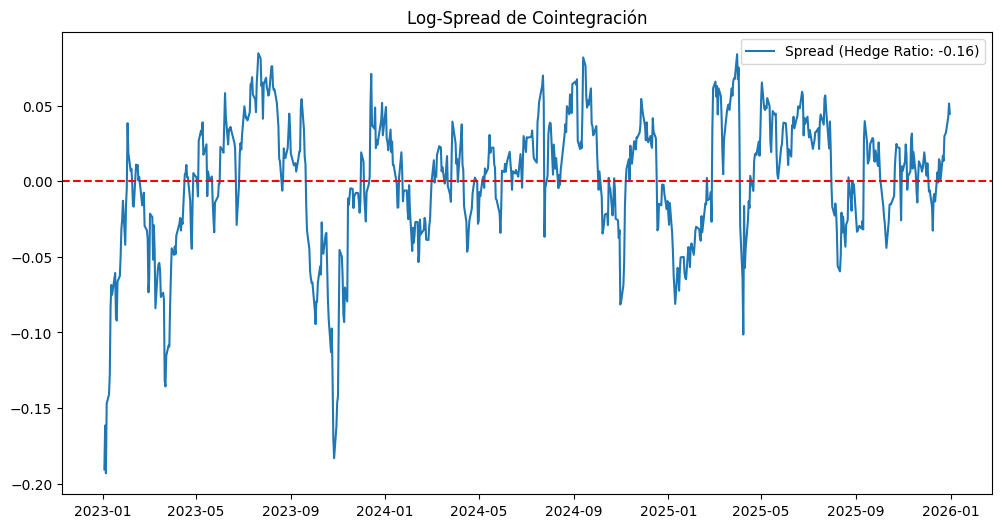

In [10]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

def extract_and_construct_spread(ticker_A, ticker_B, start_date, end_date):
    """
    Descarga datos, calcula el Hedge Ratio via OLS y construye el Spread.
    
    Args:
        ticker_A (str): Ticker del activo dependiente (ej. 'GLD').
        ticker_B (str): Ticker del activo independiente (ej. 'GDX').
        start_date (str): Fecha inicio 'YYYY-MM-DD'.
        end_date (str): Fecha fin 'YYYY-MM-DD'.
        
    Returns:
        pd.Series: El spread histórico (z-score).
        float: El Hedge Ratio (beta).
    """
    
    # 1. Descarga de datos (Solo 'Adj Close' para ajustar por dividendos/splits)
    print(f"Descargando {ticker_A} y {ticker_B}...")
    data = yf.download([ticker_A, ticker_B], start=start_date, end=end_date, auto_adjust=False)['Adj Close']
    
    # Limpieza de datos (eliminar filas con NaN)
    data = data.dropna()
    
    if data.empty:
        raise ValueError("No se descargaron datos. Verifica los tickers o fechas.")

    # 2. Convertir a Log-Precios
    # Usamos log natural
    log_A = np.log(data[ticker_A])
    log_B = np.log(data[ticker_B])
    
    # 3. Calcular Hedge Ratio (Beta) usando OLS (Mínimos Cuadrados Ordinarios)
    # Ecuación: log_A = beta * log_B + alpha + error
    # Añadimos una constante (intercepto/alpha) a la regresión
    X = sm.add_constant(log_B)
    model = sm.OLS(log_A, X).fit()
    
    alpha = model.params['const']
    beta = model.params[ticker_B]
    
    print(f"Hedge Ratio (Beta): {beta:.4f}")
    print(f"R-squared: {model.rsquared:.4f}")
    
    # 4. Construir el Spread Bruto
    # spread = y - (beta * x + alpha)
    # Nota: En trading real, a veces ignoramos alpha y solo operamos A - beta*B
    # Pero para el modelo OU riguroso, usamos el residuo completo.
    raw_spread = log_A - (beta * log_B + alpha)
    
    # 5. Test de Estacionariedad (ADF Test)
    # El spread DEBE ser estacionario para que funcione el par.
    adf_result = adfuller(raw_spread)
    print(f"ADF Statistic: {adf_result[0]:.4f}")
    print(f"p-value: {adf_result[1]:.4f}")
    
    if adf_result[1] > 0.05:
        print("ALERTA: El spread NO es estacionario")
    else:
        print("ÉXITO: El spread es estacionario.")

    return raw_spread, beta

# --- EJECUCIÓN ---
# Ejemplo clásico: Oro (GLD) vs Mineras de Oro (GDX)
# Nota: En 2026 este par está muy arbitrado, pero sirve de ejemplo académico.
try:
    spread_series, hedge_ratio = extract_and_construct_spread('INVH', 'WBD', '2023-01-01', '2026-01-01')

    # Visualización rápida
    plt.figure(figsize=(12, 6))
    plt.plot(spread_series, label=f'Spread (Hedge Ratio: {hedge_ratio:.2f})')
    plt.axhline(spread_series.mean(), color='red', linestyle='--')
    plt.title('Log-Spread de Cointegración')
    plt.legend()
    plt.show()
    
except Exception as e:
    print(f"Error: {e}")

#### Proceso de Ornstein Ulenbeck

Ajustamos el siguiente modelo de Ornstein Ulenbeck a nuestro spread. Debemos usar la solución para tiempo discreto $\Delta t$:

$$ Z_t = Z_{t-1}e^{-\theta \Delta t} + \mu (1- e^{-\theta \Delta t}) + \epsilon_t$$

$$\text{Var}(\epsilon_t) = \sigma^2 \frac{1 - e^{-2\theta \Delta t}}{2\theta}$$

In [11]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

def fit_ou_process(spread: pd.Series, dt: float = 1.0) -> dict:
    """
    Fits an Ornstein-Uhlenbeck process to a stationary discrete time series.
    
    Parameters:
    spread (pd.Series): The stationary spread Z_t.
    dt (float): The time step (default is 1.0 for daily data to get half-life in days).
    
    Returns:
    dict: The continuous-time OU parameters (theta, mu, sigma) and the half-life.
    """
    # 1. Prepare the lagged data for AR(1) regression
    y = spread.values[1:]          # Z_t
    x = spread.values[:-1]         # Z_{t-1}
    
    # 2. Add intercept for the OLS regression (a + b * Z_{t-1})
    X = sm.add_constant(x)
    
    # 3. Fit the Ordinary Least Squares (OLS) model
    ols_model = sm.OLS(y, X).fit()
    a, b = ols_model.params
    
    # Calculate the variance of the residuals
    var_epsilon = np.var(ols_model.resid, ddof=2)
    
    # 4. Map discrete AR(1) parameters to continuous OU parameters
    # If b >= 1, the series is NOT stationary (unit root or explosive).
    if b >= 1:
        raise ValueError("The AR(1) coefficient is >= 1. The spread is not stationary. Check your ADF test.")
    if b <= 0:
        raise ValueError("The AR(1) coefficient is <= 0. The series oscillates deterministically.")
        
    theta = -np.log(b) / dt
    mu = a / (1 - b)
    sigma = np.sqrt((2 * theta * var_epsilon) / (1 - b**2))
    
    # 5. Calculate Half-Life
    half_life = np.log(2) / theta
    
    # 6. Calculate the equilibrium Z-score boundaries
    # The equilibrium standard deviation of the spread is NOT the sample standard deviation.
    # It is derived from the OU parameters: sigma_eq = sqrt(sigma^2 / 2*theta)
    sigma_eq = np.sqrt((sigma**2) / (2 * theta))
    
    return {
        'theta': theta,
        'mu': mu,
        'sigma': sigma,
        'half_life': half_life,
        'sigma_eq': sigma_eq,
        'r_squared': ols_model.rsquared
    }

# --- Usage Example ---
# Assuming `Z_t` is a pandas Series of your fractionally differenced, cointegrated spread.
ou_params = fit_ou_process(spread_series, dt=1.0)
print(f"Mean Reversion Rate (Theta): {ou_params['theta']:.4f}")
print(f"Equilibrium Mean (Mu):       {ou_params['mu']:.4f}")
print(f"Half-Life (days):            {ou_params['half_life']:.2f}")

# Calculate dimensionless z-score for trading execution:
z_score_t = (spread_series.iloc[-1] - ou_params['mu']) / ou_params['sigma_eq']

Mean Reversion Rate (Theta): 0.0837
Equilibrium Mean (Mu):       0.0038
Half-Life (days):            8.29


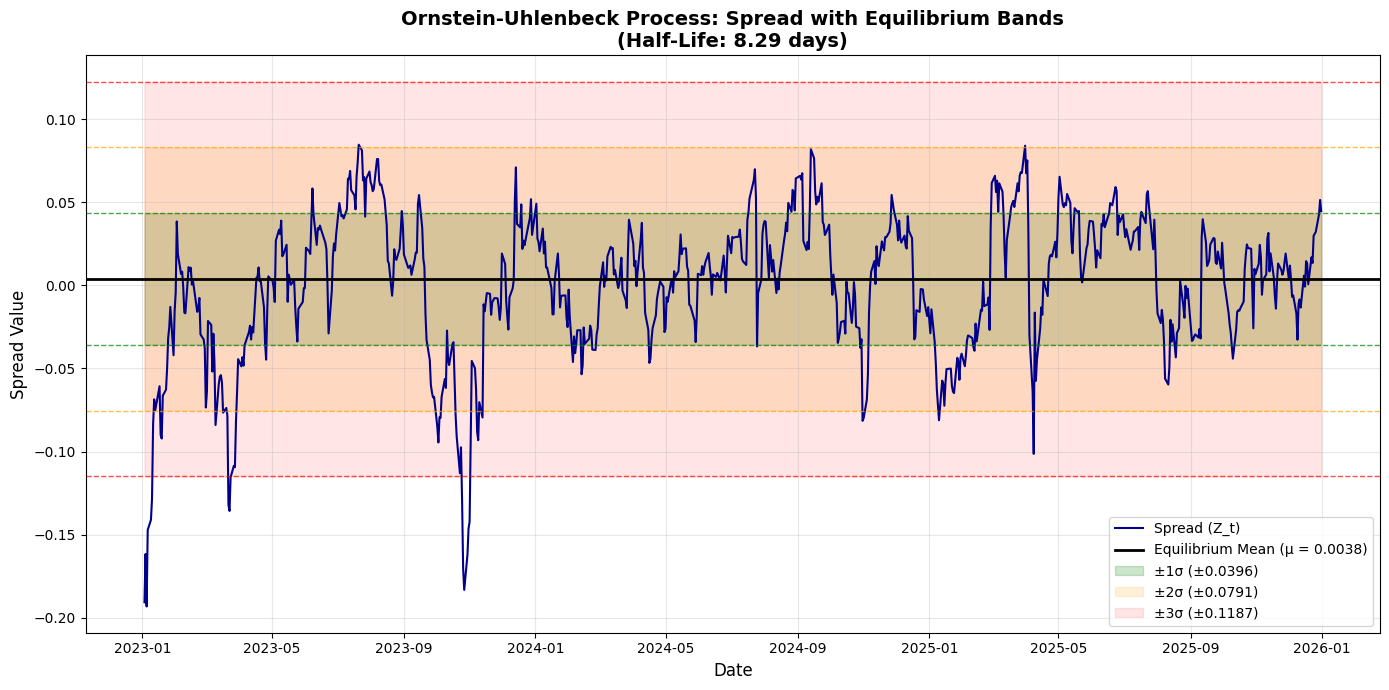

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def plot_ou_process(spread: pd.Series, ou_params: dict):
    """
    Visualizes the Ornstein-Uhlenbeck process with the spread and equilibrium bands.
    
    Parameters:
    spread (pd.Series): The stationary spread Z_t.
    ou_params (dict): Output from fit_ou_process() containing theta, mu, sigma, sigma_eq.
    """
    mu = ou_params['mu']
    sigma_eq = ou_params['sigma_eq']
    half_life = ou_params['half_life']
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Plot the spread
    ax.plot(spread.index, spread.values, color='darkblue', linewidth=1.5, label='Spread (Z_t)')
    
    # Plot the equilibrium mean
    ax.axhline(mu, color='black', linestyle='-', linewidth=2, label=f'Equilibrium Mean (μ = {mu:.4f})')
    
    # Plot confidence bands (1-sigma, 2-sigma, 3-sigma)
    ax.fill_between(spread.index, mu - sigma_eq, mu + sigma_eq, 
                    color='green', alpha=0.2, label=f'±1σ (±{sigma_eq:.4f})')
    ax.fill_between(spread.index, mu - 2*sigma_eq, mu + 2*sigma_eq, 
                    color='orange', alpha=0.15, label=f'±2σ (±{2*sigma_eq:.4f})')
    ax.fill_between(spread.index, mu - 3*sigma_eq, mu + 3*sigma_eq, 
                    color='red', alpha=0.1, label=f'±3σ (±{3*sigma_eq:.4f})')
    
    # Plot the sigma bands as lines
    ax.axhline(mu + sigma_eq, color='green', linestyle='--', linewidth=1, alpha=0.7)
    ax.axhline(mu - sigma_eq, color='green', linestyle='--', linewidth=1, alpha=0.7)
    ax.axhline(mu + 2*sigma_eq, color='orange', linestyle='--', linewidth=1, alpha=0.7)
    ax.axhline(mu - 2*sigma_eq, color='orange', linestyle='--', linewidth=1, alpha=0.7)
    ax.axhline(mu + 3*sigma_eq, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.axhline(mu - 3*sigma_eq, color='red', linestyle='--', linewidth=1, alpha=0.7)
    
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Spread Value', fontsize=12)
    ax.set_title(f'Ornstein-Uhlenbeck Process: Spread with Equilibrium Bands\n(Half-Life: {half_life:.2f} days)', 
                 fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# --- Plot the OU Process ---
plot_ou_process(spread_series, ou_params)

[*********************100%***********************]  2 of 2 completed


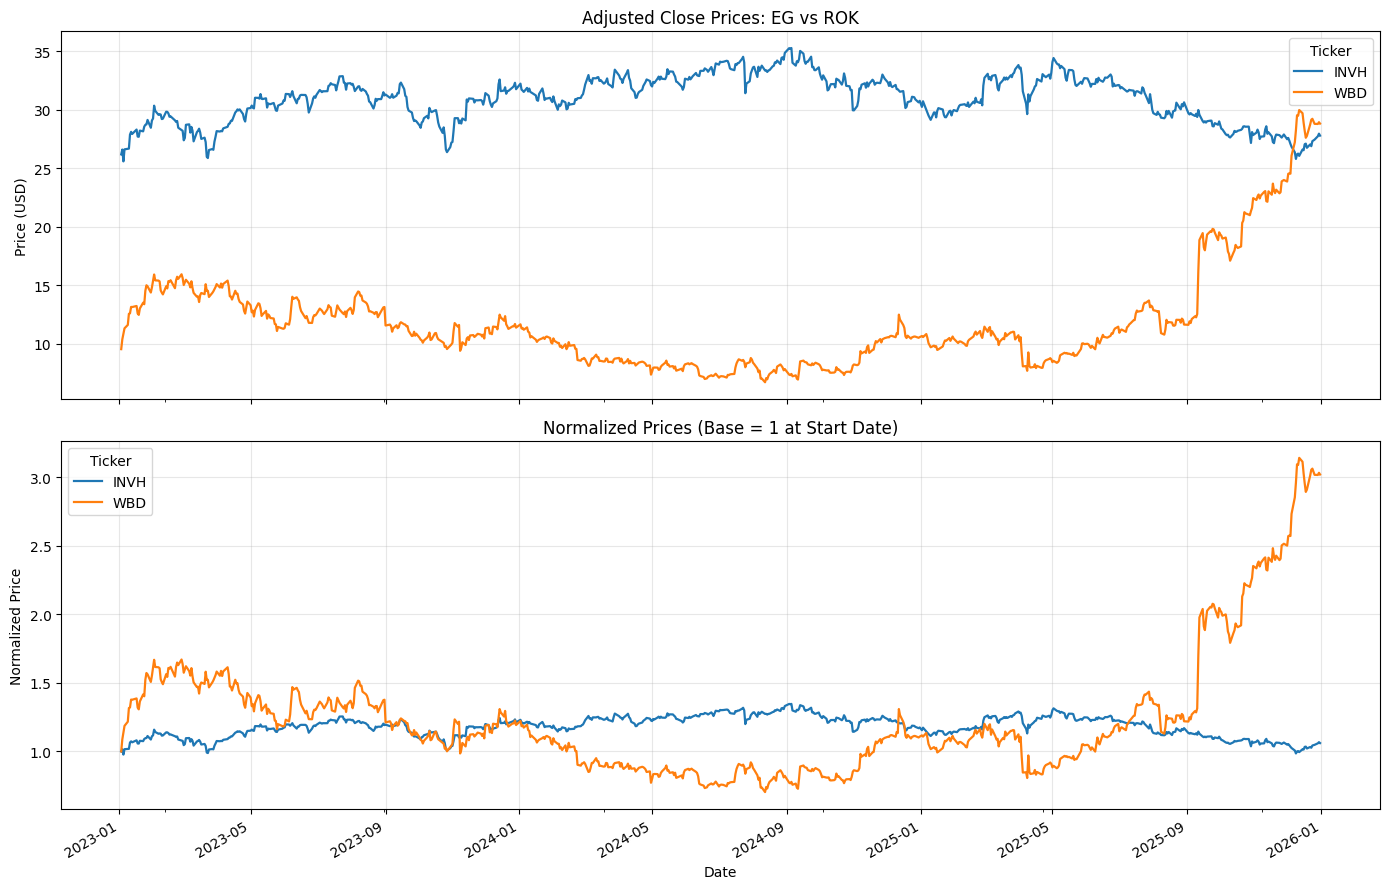

In [15]:
# Plot pair prices (EG, ROK)
import yfinance as yf
import matplotlib.pyplot as plt

t1 = 'INVH'
t2 = 'WBD'
pair = [t1, t2]
start_date = '2023-01-01'
end_date = '2026-01-01'

prices = yf.download(pair, start=start_date, end=end_date, auto_adjust=False)['Adj Close'].dropna()

if prices.empty:
    print('No prices were downloaded. Check tickers or date range.')
else:
    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

    # Raw adjusted close prices
    prices.plot(ax=axes[0], linewidth=1.6)
    axes[0].set_title('Adjusted Close Prices: EG vs ROK')
    axes[0].set_ylabel('Price (USD)')
    axes[0].grid(alpha=0.3)

    # Normalized prices for relative comparison
    normalized = prices / prices.iloc[0]
    normalized.plot(ax=axes[1], linewidth=1.6)
    axes[1].set_title('Normalized Prices (Base = 1 at Start Date)')
    axes[1].set_ylabel('Normalized Price')
    axes[1].set_xlabel('Date')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()